# Imports

In [14]:
import warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

# Pegando os dados

In [15]:
df_modelo = pd.read_csv("data/Pilgrim_s_Pride_Corporation_2.csv")
TARGET = "Close"
DATE_COLUMN = "Date"
SEASONAL_PERIOD = 76

df_modelo[DATE_COLUMN] = pd.to_datetime(
    df_modelo[DATE_COLUMN], errors="coerce", utc=True
).dt.tz_localize(None)
df_modelo = df_modelo.dropna(subset=[DATE_COLUMN])
df_modelo = df_modelo.loc[df_modelo[DATE_COLUMN] >= pd.Timestamp("2013-01-01")].copy()
df_modelo = (
    df_modelo.set_index(DATE_COLUMN)
    .sort_index()
    .drop(columns=["Open", "High", "Low", "Volume", "USD_MXN"], errors="ignore")
)
df_escalonado = df_modelo.copy()
print(f"Dados ordenados: {df_modelo.index.is_monotonic_increasing}")

Dados ordenados: True


In [16]:
test_size = int(len(df_modelo) * 0.25)
train_original = df_modelo[TARGET].iloc[:-test_size]
test_original = df_modelo[TARGET].iloc[-test_size:]
train = train_original
test = test_original
print(f"Treino: {len(train)} observações | Teste: {len(test)} observações")

Treino: 2573 observações | Teste: 857 observações


# Buscando o melhor RandomForest

In [21]:
import importlib
import model_utils
importlib.reload(model_utils)

import optuna
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from model_utils import (
    calculate_metrics,
    evaluate_baselines,
    update_model_result,
    walk_forward_predict,
)

dados = df_modelo.copy()
PERIODO_SAZONAL = 76
WALK_FORWARD_STEP = 50
colunas_features = [coluna for coluna in dados.columns if coluna not in [TARGET, DATE_COLUMN]]
historico = dados[colunas_features + [TARGET]].shift(1)
X = pd.DataFrame(index=dados.index)

periodos_lag = [1, 2, 3, 7, 14, 30, PERIODO_SAZONAL, 2 * PERIODO_SAZONAL]
for coluna in historico.columns:
    for periodo in periodos_lag:
        X[f"{coluna}_lag_{periodo}"] = historico[coluna].shift(periodo - 1)

for coluna in historico.columns:
    X[f"{coluna}_delta_1"] = historico[coluna] - historico[coluna].shift(1)
    X[f"{coluna}_delta_sazonal"] = historico[coluna] - historico[coluna].shift(PERIODO_SAZONAL - 1)

for janela in [3, 7, 14, 30, PERIODO_SAZONAL]:
    for coluna in historico.columns:
        serie = historico[coluna]
        X[f"{coluna}_media_{janela}"] = serie.rolling(janela).mean()
        X[f"{coluna}_desvio_{janela}"] = serie.rolling(janela).std()

alvo_historico = historico[TARGET]
X[f"{TARGET}_delta_3"] = alvo_historico - alvo_historico.shift(3)
X[f"{TARGET}_delta_7"] = alvo_historico - alvo_historico.shift(7)
X[f"{TARGET}_delta_30"] = alvo_historico - alvo_historico.shift(30)
X[f"{TARGET}_media_sazonal"] = alvo_historico.rolling(PERIODO_SAZONAL).mean()
X[f"{TARGET}_desvio_sazonal"] = alvo_historico.rolling(PERIODO_SAZONAL).std()

y = dados[TARGET]
base_modelo = pd.concat([X, y], axis=1).dropna()
X = base_modelo.drop(columns=[TARGET])
y = base_modelo[TARGET]

h_modelo = int(len(X) * 0.25)
X_train = X.iloc[:-h_modelo]
X_test = X.iloc[-h_modelo:]
y_train = y.iloc[:-h_modelo]
y_test = y.iloc[-h_modelo:]
tscv = TimeSeriesSplit(n_splits=5)

def objetivo(trial):
    modelo = RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 800),
        max_depth=trial.suggest_int("max_depth", 3, 30),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 1.0]),
        bootstrap=trial.suggest_categorical("bootstrap", [True, False]),
        random_state=42,
        n_jobs=-1
    )
    erros = []
    for treino_idx, validacao_idx in tscv.split(X_train):
        modelo.fit(X_train.iloc[treino_idx], y_train.iloc[treino_idx])
        previsoes = modelo.predict(X_train.iloc[validacao_idx])
        erros.append(mean_absolute_error(y_train.iloc[validacao_idx], previsoes))
    return np.mean(erros)

estudo = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
estudo.optimize(objetivo, n_trials=50, show_progress_bar=True)

modelo_factory = lambda: RandomForestRegressor(
    **estudo.best_params, random_state=42, n_jobs=-1
)
melhor_modelo = modelo_factory()
melhor_modelo.fit(X_train, y_train)
previsoes_teste = walk_forward_predict(
    modelo_factory, X_train, y_train, X_test, y_test, step=WALK_FORWARD_STEP
)
metrics_rf = calculate_metrics(y_test, previsoes_teste)
baselines_rf = evaluate_baselines(train_original, test_original, PERIODO_SAZONAL)

print("Quantidade de features:", X.shape[1])
print("Walk-forward: refit a cada", WALK_FORWARD_STEP, "observações")
print("Melhores parâmetros:", estudo.best_params)
print("Métricas RandomForest walk-forward:", metrics_rf)
print("Baselines:", baselines_rf)

[I 2026-10-04 11:56:52,950] A new study created in memory with name: no-name-0d7a63fb-5eb9-4839-83db-595426420f17
Best trial: 0. Best value: 0.833026:   2%|▏         | 1/50 [00:02<01:53,  2.31s/it]

[I 2026-10-04 11:56:55,256] Trial 0 finished with value: 0.8330257904157572 and parameters: {'n_estimators': 362, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.8330257904157572.


Best trial: 0. Best value: 0.833026:   4%|▍         | 2/50 [00:04<01:55,  2.41s/it]

[I 2026-10-04 11:56:57,741] Trial 1 finished with value: 1.0615605895248388 and parameters: {'n_estimators': 596, 'max_depth': 3, 'min_samples_split': 20, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 0.8330257904157572.


Best trial: 2. Best value: 0.587857:   6%|▌         | 3/50 [00:11<03:23,  4.33s/it]

...

[I 2026-10-04 12:01:50,842] Trial 47 finished with value: 0.5547109837168378 and parameters: {'n_estimators': 661, 'max_depth': 28, 'min_samples_split': 19, 'min_samples_leaf': 8, 'max_features': 1.0, 'bootstrap': True}. Best is trial 41 with value: 0.5531177985475438.


Best trial: 41. Best value: 0.553118:  98%|█████████▊| 49/50 [05:06<00:09,  9.89s/it]

[I 2026-10-04 12:01:59,869] Trial 48 finished with value: 0.5547219537641215 and parameters: {'n_estimators': 650, 'max_depth': 26, 'min_samples_split': 19, 'min_samples_leaf': 8, 'max_features': 1.0, 'bootstrap': True}. Best is trial 41 with value: 0.5531177985475438.


Best trial: 41. Best value: 0.553118: 100%|██████████| 50/50 [05:17<00:00,  6.36s/it]


[I 2026-10-04 12:02:10,912] Trial 49 finished with value: 0.5534397938666661 and parameters: {'n_estimators': 782, 'max_depth': 25, 'min_samples_split': 20, 'min_samples_leaf': 6, 'max_features': 1.0, 'bootstrap': True}. Best is trial 41 with value: 0.5531177985475438.
Quantidade de features: 85
Walk-forward: refit a cada 50 observações
Melhores parâmetros: {'n_estimators': 768, 'max_depth': 26, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_features': 1.0, 'bootstrap': True}
Métricas RandomForest walk-forward: {'mae': 1.3043396960094051, 'rmse': 2.070108528306659, 'mape': 3.4403155496445312, 'smape': 3.512372451155225, 'wape': 3.747786907205694}
Baselines: {'naive': {'mae': 15.032457984830806, 'rmse': 17.409610930895454, 'mape': 39.643745639959135, 'smape': 52.23992173142592, 'wape': 44.06902675458048}, 'seasonal_naive': {'mae': 14.688274061843641, 'rmse': 17.06490497779233, 'mape': 38.70747756294008, 'smape': 50.6694518891883, 'wape': 43.060020075438345}}


## Análise de resíduos e feature importance

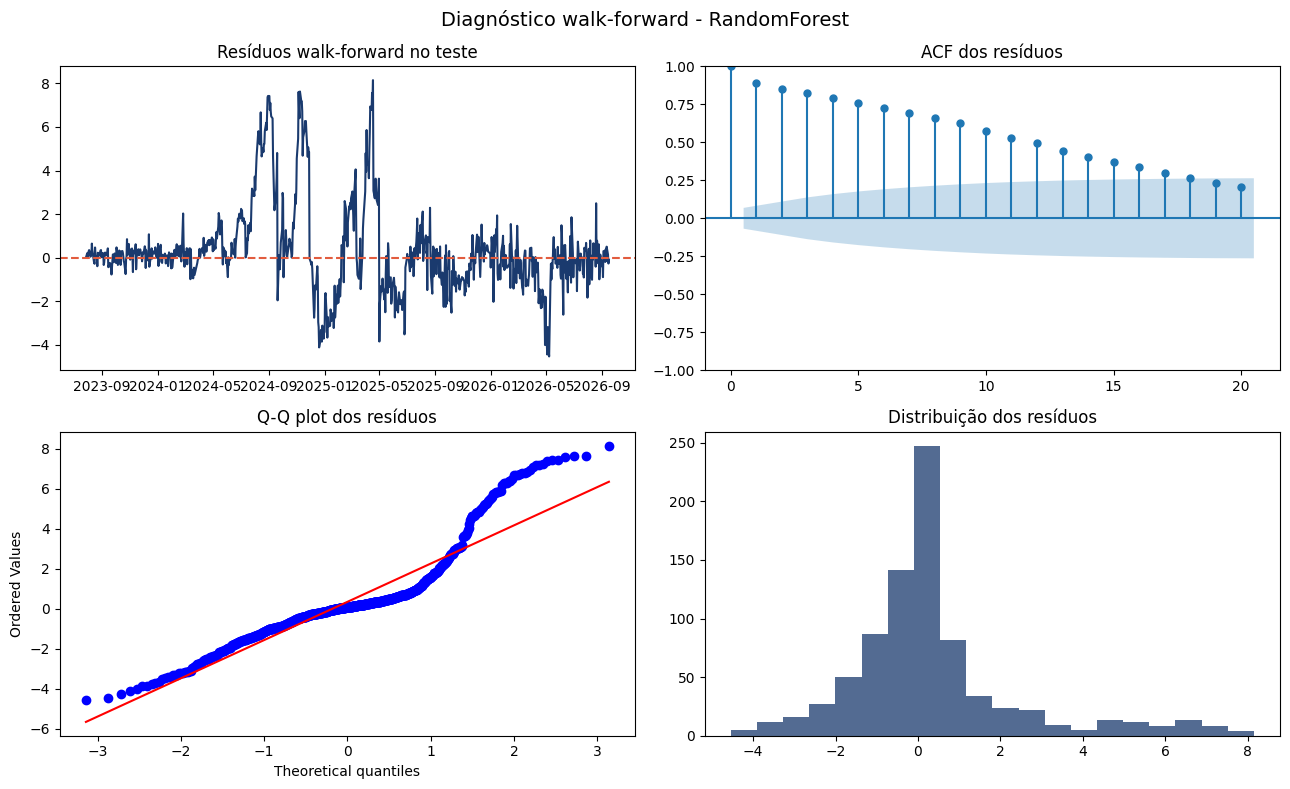

Métricas walk-forward: {'mae': 1.3043396960094051, 'rmse': 2.070108528306659, 'mape': 3.4403155496445312, 'smape': 3.512372451155225, 'wape': 3.747786907205694}


,lb_stat,lb_pvalue
1,650.9312,0.0
2,1247.3660,0.0
3,1805.2434,0.0
4,2322.2178,0.0
5,2800.3858,0.0
6,3236.0470,0.0
7,3633.9799,0.0
8,3992.8320,0.0
9,4317.1243,0.0
10,4589.2351,0.0


Importância SHAP do RandomForest:


,mean_abs_shap
Close_lag_1,5.861005
Close_media_3,0.147532
CALM_Close_delta_sazonal,0.051604
Close_lag_2,0.029463
XLP_Close_media_76,0.009310
CALM_Close_lag_76,0.005510
Close_delta_sazonal,0.004280
CALM_Close_desvio_76,0.004044
Close_media_14,0.003844
Close_delta_1,0.003531


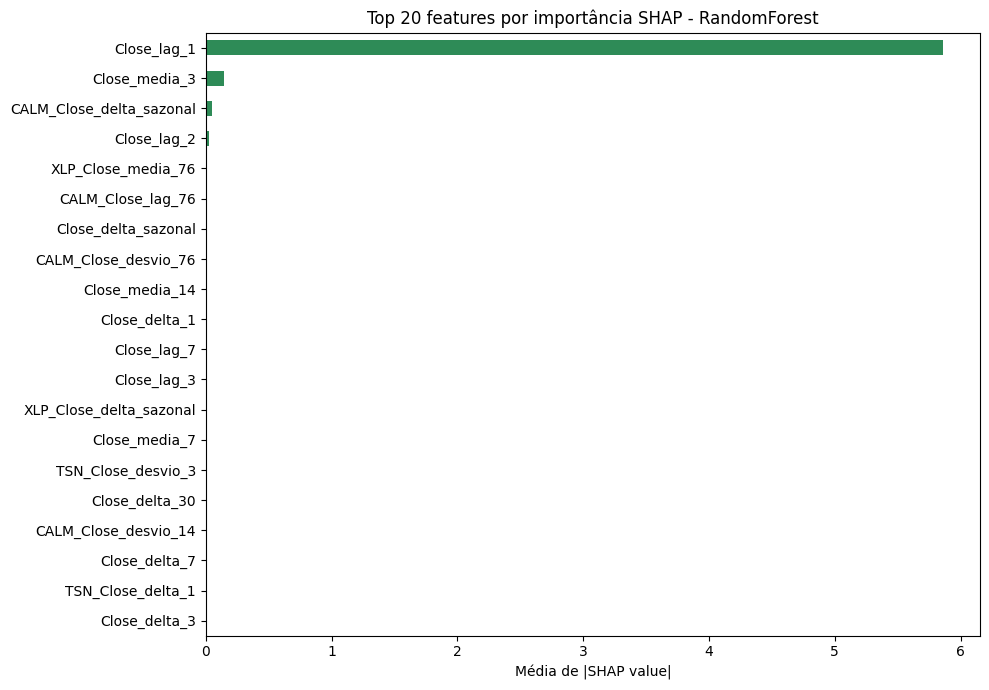

In [22]:
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

residuos_teste = pd.Series(
    y_test.to_numpy() - previsoes_teste,
    index=y_test.index,
    name="residuo"
).dropna()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].plot(residuos_teste.index, residuos_teste, color="#1a3a6e")
axes[0, 0].axhline(0, color="#e25c3e", linestyle="--")
axes[0, 0].set_title("Resíduos walk-forward no teste")
plot_acf(residuos_teste, lags=min(20, len(residuos_teste) - 2), ax=axes[0, 1], title="ACF dos resíduos")
stats.probplot(residuos_teste, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q plot dos resíduos")
axes[1, 1].hist(residuos_teste, bins=20, color="#1a3a6e", alpha=0.75)
axes[1, 1].set_title("Distribuição dos resíduos")
plt.suptitle("Diagnóstico walk-forward - RandomForest", fontsize=14)
plt.tight_layout()
plt.show()

lags_ljung = min(12, len(residuos_teste) // 5)
ljung_box = acorr_ljungbox(residuos_teste, lags=lags_ljung, return_df=True)
print("Métricas walk-forward:", metrics_rf)
display(ljung_box[["lb_stat", "lb_pvalue"]].round(4))

amostra_shap = X_test.iloc[:min(300, len(X_test))]
explainer_shap = shap.TreeExplainer(melhor_modelo)
shap_values = explainer_shap(amostra_shap)
importancias_shap_rf = pd.Series(
    np.abs(shap_values.values).mean(axis=0), index=amostra_shap.columns
).sort_values(ascending=False)
print("Importância SHAP do RandomForest:")
display(importancias_shap_rf.head(20).rename("mean_abs_shap").to_frame())

plt.figure(figsize=(10, 7))
importancias_shap_rf.head(20).sort_values().plot(kind="barh", color="#2e8b57")
plt.title("Top 20 features por importância SHAP - RandomForest")
plt.xlabel("Média de |SHAP value|")
plt.tight_layout()
plt.show()

In [ ]:
melhores_params = estudo.best_params
MAE_FINAL = metrics_rf["mae"]

In [23]:
resultado_rf = update_model_result(
    "all_modelos.json",
    "RandomForest",
    metrics_rf,
    params=estudo.best_params,
    extra={
        "baselines": baselines_rf,
        "n_features": int(X.shape[1]),
        "walk_forward_step": WALK_FORWARD_STEP,
        "shap_importance": importancias_shap_rf.head(20).to_dict()
    }
)
print(resultado_rf)

{'modelo': 'RandomForest', 'mae': 1.3043396960094051, 'rmse': 2.070108528306659, 'mape': 3.4403155496445312, 'smape': 3.512372451155225, 'wape': 3.747786907205694, 'params': {'n_estimators': 768, 'max_depth': 26, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_features': 1.0, 'bootstrap': True}, 'baselines': {'naive': {'mae': 15.032457984830806, 'rmse': 17.409610930895454, 'mape': 39.643745639959135, 'smape': 52.23992173142592, 'wape': 44.06902675458048}, 'seasonal_naive': {'mae': 14.688274061843641, 'rmse': 17.06490497779233, 'mape': 38.70747756294008, 'smape': 50.6694518891883, 'wape': 43.060020075438345}}, 'n_features': 85, 'walk_forward_step': 50, 'shap_importance': {'Close_lag_1': 5.86100544947133, 'Close_media_3': 0.14753228256853937, 'CALM_Close_delta_sazonal': 0.0516037563074192, 'Close_lag_2': 0.02946330920146045, 'XLP_Close_media_76': 0.009310180402833249, 'CALM_Close_lag_76': 0.005509598893700765, 'Close_delta_sazonal': 0.004280121445330564, 'CALM_Close_desvio_76': 0.00